In [1]:
# ==============================================================================
# CELL 0: GIẢI NÉN MODEL
# ==============================================================================
!unzip -o trained_models_active.zip
print("✅ Đã giải nén xong model!")

Archive:  trained_models_active.zip
   creating: trained_models/
 extracting: trained_models/ppo_vn_agent.zip  
 extracting: trained_models/ddpg_vn_agent.zip  
 extracting: trained_models/a2c_vn_agent.zip  
✅ Đã giải nén xong model!


In [2]:
# ==============================================================================
# CELL 1: CÀI ĐẶT & ĐỊNH NGHĨA MÔI TRƯỜNG BACKTEST
# ==============================================================================
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git -q
!pip install shimmy>=0.2.1 -q
!pip install pandas numpy matplotlib yfinance -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yfinance as yf
from stable_baselines3 import PPO, A2C, DDPG
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# --- CLASS MÔI TRƯỜNG "ACTIVE" (Giống hệt File 2) ---
class StockTradingEnvVietnam_Active(StockTradingEnv):
    def __init__(self,
                 buy_cost_pct=0.0015, sell_cost_pct=0.0015, sell_tax_pct=0.001,
                 min_trading_lot=100, settlement_cycle=3,
                 stop_loss_pct=-0.07, take_profit_pct=0.15,
                 max_order_pct=0.05, max_stock_weight=0.10,
                 **kwargs):

        if 'num_stock_shares' not in kwargs:
            stock_dim = kwargs.get('stock_dim')
            kwargs['num_stock_shares'] = [0] * stock_dim
        kwargs['buy_cost_pct'] = buy_cost_pct
        kwargs['sell_cost_pct'] = sell_cost_pct
        super().__init__(**kwargs)

        self.sell_tax_pct = sell_tax_pct
        self.min_trading_lot = min_trading_lot
        self.settlement_cycle = settlement_cycle
        self.stop_loss_pct = stop_loss_pct
        self.take_profit_pct = take_profit_pct
        self.max_order_pct = max_order_pct
        self.max_stock_weight = max_stock_weight

        self.stocks_pending = np.zeros((self.stock_dim, self.settlement_cycle))
        self.cash_pending = np.zeros(self.settlement_cycle)
        self.avg_buy_price = np.zeros(self.stock_dim)

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self.stocks_pending = np.zeros((self.stock_dim, self.settlement_cycle))
        self.cash_pending = np.zeros(self.settlement_cycle)
        self.avg_buy_price = np.zeros(self.stock_dim)
        return obs, info

    def _update_settlement(self):
        self.state[0] += self.cash_pending[-1]
        self.cash_pending = np.roll(self.cash_pending, 1); self.cash_pending[0] = 0
        for i in range(self.stock_dim):
            self.state[self.stock_dim + 1 + i] += self.stocks_pending[:, -1][i]
        self.stocks_pending = np.roll(self.stocks_pending, 1, axis=1); self.stocks_pending[:, 0] = 0

    def _get_total_asset_value(self):
        cash = self.state[0] + np.sum(self.cash_pending)
        current_prices = np.array([self.state[i + 1] for i in range(self.stock_dim)])
        shares_available = np.array([self.state[self.stock_dim + 1 + i] for i in range(self.stock_dim)])
        shares_pending = np.sum(self.stocks_pending, axis=1)
        stock_value = np.sum((shares_available + shares_pending) * current_prices)
        return cash + stock_value

    def _check_stop_loss_take_profit(self):
        current_prices = np.array([self.state[i + 1] for i in range(self.stock_dim)])
        for i in range(self.stock_dim):
            shares = self.state[self.stock_dim + 1 + i]
            if shares > 0 and self.avg_buy_price[i] > 0:
                profit_pct = (current_prices[i] - self.avg_buy_price[i]) / self.avg_buy_price[i]
                if profit_pct <= self.stop_loss_pct or profit_pct >= self.take_profit_pct:
                    revenue = shares * current_prices[i] * (1 - (self.sell_cost_pct + self.sell_tax_pct))
                    self.cash_pending[0] += revenue
                    self.state[self.stock_dim + 1 + i] = 0
                    self.avg_buy_price[i] = 0
                    self.trades += 1

    def step(self, actions):
        self._update_settlement()
        self._check_stop_loss_take_profit()

        # --- FIX LỖI HIỂN THỊ TÀI SẢN (Cell 3 cũ) ---
        obs, reward, done, truncated, info = super().step(actions)

        # Tính lại asset_memory cho đúng với T+
        true_asset = self._get_total_asset_value()
        self.asset_memory[-1] = true_asset

        return obs, reward, done, truncated, info

    def _sell_stock(self, index, action):
        available = self.state[index + self.stock_dim + 1]
        if available > 0:
            share = min(abs(action) // self.min_trading_lot * self.min_trading_lot, available)
            if share > 0:
                income = self.state[index+1] * share * (1 - (self.sell_cost_pct + self.sell_tax_pct))
                self.cash_pending[0] += income
                self.state[index + self.stock_dim + 1] -= share
                if self.state[index + self.stock_dim + 1] == 0: self.avg_buy_price[index] = 0
                self.trades += 1
                return share
        return 0

    def _buy_stock(self, index, action):
        total_asset = self._get_total_asset_value()
        current_price = self.state[index+1]
        max_order_value = total_asset * self.max_order_pct # Max 5%

        shares_holding = self.state[index + self.stock_dim + 1] + np.sum(self.stocks_pending[index])
        current_holding_value = shares_holding * current_price
        max_position_value = total_asset * self.max_stock_weight # Max 10%
        remaining_room = max_position_value - current_holding_value

        if remaining_room <= 0: return 0

        available_cash = self.state[0]
        allowed_cash = min(available_cash, max_order_value, remaining_room)

        cost_per_share = current_price * (1 + self.buy_cost_pct)
        max_shares = int(allowed_cash // cost_per_share)
        shares_ai_want = action // self.min_trading_lot * self.min_trading_lot
        share = min(shares_ai_want, max_shares // self.min_trading_lot * self.min_trading_lot)

        if share > 0:
            cost = cost_per_share * share
            self.state[0] -= cost
            self.stocks_pending[index][0] += share

            # Cập nhật giá vốn
            current_total_shares = shares_holding + share
            prev_shares = shares_holding
            if prev_shares > 0:
                self.avg_buy_price[index] = (self.avg_buy_price[index] * prev_shares + current_price * share) / current_total_shares
            else:
                self.avg_buy_price[index] = current_price

            self.trades += 1
            return share
        return 0

print("✅ Đã thiết lập môi trường Backtest chuẩn 'Active Trading'.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Đã thiết lập môi trường Backtest chuẩn 'Active Trading'.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# ==============================================================================
# CELL 2: LOAD DỮ LIỆU TEST (ĐÃ FIX INDEX)
# ==============================================================================
if os.path.exists("vietnam_vn30_data.csv"):
    df = pd.read_csv("vietnam_vn30_data.csv")
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)

    # Lấy dữ liệu 2024 trở đi
    test_df = df[df.date >= '2024-01-01'].copy()

    # --- QUAN TRỌNG: RESET INDEX ĐỂ FINRL HIỂU ---
    test_df = test_df.sort_values(['date', 'tic']).reset_index(drop=True)
    test_df.index = test_df.date.factorize()[0]

    print(f"📊 Dữ liệu Test: {len(test_df)} dòng (2024 - Nay).")

    # Cấu hình môi trường Test (Phải khớp với lúc Train)
    stock_dimension = len(test_df.tic.unique())
    state_space = 1 + 2*stock_dimension + 4*stock_dimension

    env_kwargs = {
        "hmax": 5000, "initial_amount": 1000000000,
        "buy_cost_pct": 0.0015, "sell_cost_pct": 0.0015, "sell_tax_pct": 0.001,
        "min_trading_lot": 100, "settlement_cycle": 3,
        "state_space": state_space, "stock_dim": stock_dimension,
        "tech_indicator_list": ['macd', 'rsi_30', 'cci_30', 'dx_30'],
        "action_space": stock_dimension,
        "reward_scaling": 1e-4,
        "stop_loss_pct": -0.07,   # Cắt lỗ -7%
        "take_profit_pct": 0.15,  # Chốt lời +15%
        "max_order_pct": 0.05,    # Mua max 5%
        "max_stock_weight": 0.10  # Max tỷ trọng 10%
    }
else:
    print("❌ THIẾU FILE DATA!")

📊 Dữ liệu Test: 14730 dòng (2024 - Nay).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# ==============================================================================
# CELL 3: CHẠY BACKTEST
# ==============================================================================
# Lưu ý: Model đã được giải nén vào thư mục 'trained_models'
models = {
    "PPO (Active)": ("trained_models/ppo_vn_agent", PPO),
    "DDPG (Active)": ("trained_models/ddpg_vn_agent", DDPG),
    "A2C (Active)": ("trained_models/a2c_vn_agent", A2C)
}

results = {}

print("🚀 BẮT ĐẦU CUỘC ĐUA (LUẬT MỚI: DIVERSIFICATION & STOP-LOSS)...")

for name, (path, model_class) in models.items():
    if os.path.exists(f"{path}.zip"):
        print(f"🤖 Đang chạy {name}...", end=" ")
        e_test_gym = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
        model = model_class.load(path)

        state, info = e_test_gym.reset()
        done = False
        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, rewards, done, truncated, info = e_test_gym.step(action)

        df_res = pd.DataFrame(e_test_gym.asset_memory, columns=['account_value'])
        results[name] = df_res['account_value'].values
        print(f"✅ Xong (NAV: {df_res['account_value'].iloc[-1]:,.0f})")
    else:
        print(f"⚠️ Thiếu file {name} ({path})")

# Vẽ biểu đồ
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# Tải benchmark
try:
    vnindex = yf.download("VNM", start="2024-01-01", end="2025-12-31", progress=False)['Close']
    vnindex = vnindex.reset_index()
    vnindex.columns = ['date', 'vnindex']
    # Chuẩn hóa về %
    base_idx = vnindex['vnindex'].iloc[0]
    plt.plot(pd.to_datetime(vnindex['date']), (vnindex['vnindex']/base_idx - 1)*100,
             label='VNM ETF (Market)', color='gray', linestyle='--')
except:
    pass

dates = test_df.date.unique()
for name, values in results.items():
    # Pad dữ liệu nếu thiếu
    if len(values) < len(dates): values = np.pad(values, (0, len(dates)-len(values)), 'edge')
    values = values[:len(dates)]

    returns = (values / 1_000_000_000 - 1) * 100
    plt.plot(dates, returns, label=name, linewidth=2)

plt.title("HIỆU SUẤT TRADING THỰC CHIẾN (Kỷ luật & Đa dạng hóa)", fontsize=16)
plt.ylabel("Lợi nhuận (%)")
plt.legend()
plt.show()

🚀 BẮT ĐẦU CUỘC ĐUA (LUẬT MỚI: DIVERSIFICATION & STOP-LOSS)...
🤖 Đang chạy PPO (Active)... ✅ Xong (NAV: 1,000,000,000)
🤖 Đang chạy DDPG (Active)... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Xong (NAV: 1,430,901,482)
🤖 Đang chạy A2C (Active)... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Xong (NAV: 1,738,732,901)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# ==============================================================================
# CELL 4: SOI LỆNH CHI TIẾT (AUDIT LOG)
# ==============================================================================
def run_audit(model_path, model_name, model_class):
    if not os.path.exists(model_path + ".zip"): return

    print(f"\n🕵️‍♂️ ĐANG KIỂM TOÁN: {model_name}...")
    env = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
    model = model_class.load(model_path)

    state, _ = env.reset()
    history = []

    # Danh sách mã
    try: tickers = env.df.tic.unique().tolist()
    except: tickers = test_df.tic.unique().tolist()

    done = False
    day_count = 0

    # Theo dõi danh mục riêng để đối chiếu
    portfolio_tracker = {tic: 0 for tic in tickers}

    while not done:
        action, _ = model.predict(state, deterministic=True)

        # Snapshot trước khi step
        cash_before = env.state[0]
        holdings_before = [env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)]

        # Step
        state, _, done, _, _ = env.step(action)

        # Snapshot sau khi step
        cash_after = env.state[0]
        holdings_after = [env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)]

        current_date = test_df.iloc[day_count * len(tickers)]['date']

        # --- PHÂN TÍCH THAY ĐỔI ĐỂ SUY RA HÀNH ĐỘNG ---
        # 1. Kiểm tra MUA/BÁN thường
        for i, tic in enumerate(tickers):
            change = holdings_after[i] - holdings_before[i] # Lưu ý: Đây chỉ là hàng khả dụng
            # Tuy nhiên, nếu mua thì hàng vào pending, holding chưa tăng ngay.
            # Nếu bán thì holding giảm ngay.

            # Kiểm tra pending (Hàng chờ về)
            pending_today = env.stocks_pending[i][0]

            if pending_today > 0: # CÓ LỆNH MUA KHỚP
                price = state[1 + i]
                val = pending_today * price
                history.append({'Ngày': current_date, 'Mã': tic, 'Lệnh': 'MUA',
                                'SL': pending_today, 'Giá trị': int(val), 'Lý do': 'AI Mua (Max 5%)'})

            if change < 0: # CÓ LỆNH BÁN KHỚP (Hoặc bị cưỡng chế bán)
                # Ta cần check xem AI muốn bán hay bị Force Sell
                # Nếu action < 0 -> AI bán. Nếu action >= 0 mà hàng vẫn giảm -> Force Sell
                act = action[i]
                price = state[1 + i]
                sl_sold = abs(change)
                val = sl_sold * price

                reason = "AI Bán"
                if act >= 0:
                    reason = "⚡ FORCE SELL (TP/SL)" # AI không bảo bán mà hàng bị mất -> Chạm SL/TP

                history.append({'Ngày': current_date, 'Mã': tic, 'Lệnh': 'BÁN',
                                'SL': sl_sold, 'Giá trị': int(val), 'Lý do': reason})

        day_count += 1

    df_log = pd.DataFrame(history)
    if not df_log.empty:
        df_log['Ngày'] = pd.to_datetime(df_log['Ngày']).dt.date
        print(f"   - Tổng số lệnh: {len(df_log)}")
        print(f"   - Số lần bị Cưỡng chế bán (Force Sell): {len(df_log[df_log['Lý do'].str.contains('FORCE')])}")

        # Đếm số mã đã từng mua
        bought_tickers = df_log[df_log['Lệnh'] == 'MUA']['Mã'].unique()
        print(f"   - Số mã cổ phiếu đã mua: {len(bought_tickers)} (Yêu cầu > 10)")

        display(df_log.head(10))
        display(df_log.tail(10))
    else:
        print("   - Không có giao dịch nào.")

# Chạy audit cho DDPG (Model hung hăng nhất)
run_audit("trained_models/ddpg_vn_agent", "DDPG Active", DDPG)


🕵️‍♂️ ĐANG KIỂM TOÁN: DDPG Active...
   - Tổng số lệnh: 834
   - Số lần bị Cưỡng chế bán (Force Sell): 155
   - Số mã cổ phiếu đã mua: 11 (Yêu cầu > 10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã,Lệnh,SL,Giá trị,Lý do
0,2024-01-02,BVH,MUA,1300.0,49601850,AI Mua (Max 5%)
1,2024-01-02,FPT,MUA,700.0,49109167,AI Mua (Max 5%)
2,2024-01-02,HPG,MUA,2300.0,48439392,AI Mua (Max 5%)
3,2024-01-02,MBB,MUA,4200.0,50624388,AI Mua (Max 5%)
4,2024-01-02,MSN,MUA,700.0,48230000,AI Mua (Max 5%)
5,2024-01-02,MWG,MUA,1200.0,50701650,AI Mua (Max 5%)
6,2024-01-02,POW,MUA,5000.0,47899160,AI Mua (Max 5%)
7,2024-01-02,SHB,MUA,5000.0,40720720,AI Mua (Max 5%)
8,2024-01-02,SSB,MUA,2300.0,47176247,AI Mua (Max 5%)
9,2024-01-02,VJC,MUA,400.0,43080000,AI Mua (Max 5%)


,Ngày,Mã,Lệnh,SL,Giá trị,Lý do
824,2025-12-16,HPG,MUA,100.0,2640000,AI Mua (Max 5%)
825,2025-12-16,MBB,BÁN,2000.0,48800000,⚡ FORCE SELL (TP/SL)
826,2025-12-16,SHB,MUA,100.0,1570000,AI Mua (Max 5%)
827,2025-12-16,VJC,MUA,200.0,37020000,AI Mua (Max 5%)
828,2025-12-16,VRE,MUA,2300.0,68310000,AI Mua (Max 5%)
829,2025-12-17,BVH,MUA,100.0,5340000,AI Mua (Max 5%)
830,2025-12-17,HPG,MUA,100.0,2640000,AI Mua (Max 5%)
831,2025-12-17,MSN,MUA,100.0,7400000,AI Mua (Max 5%)
832,2025-12-17,VJC,MUA,200.0,38780000,AI Mua (Max 5%)
833,2025-12-17,VRE,MUA,300.0,9105000,AI Mua (Max 5%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


📉 Đang tải dữ liệu thị trường làm tham chiếu...
✅ Đã thêm Benchmark: VNM ETF


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


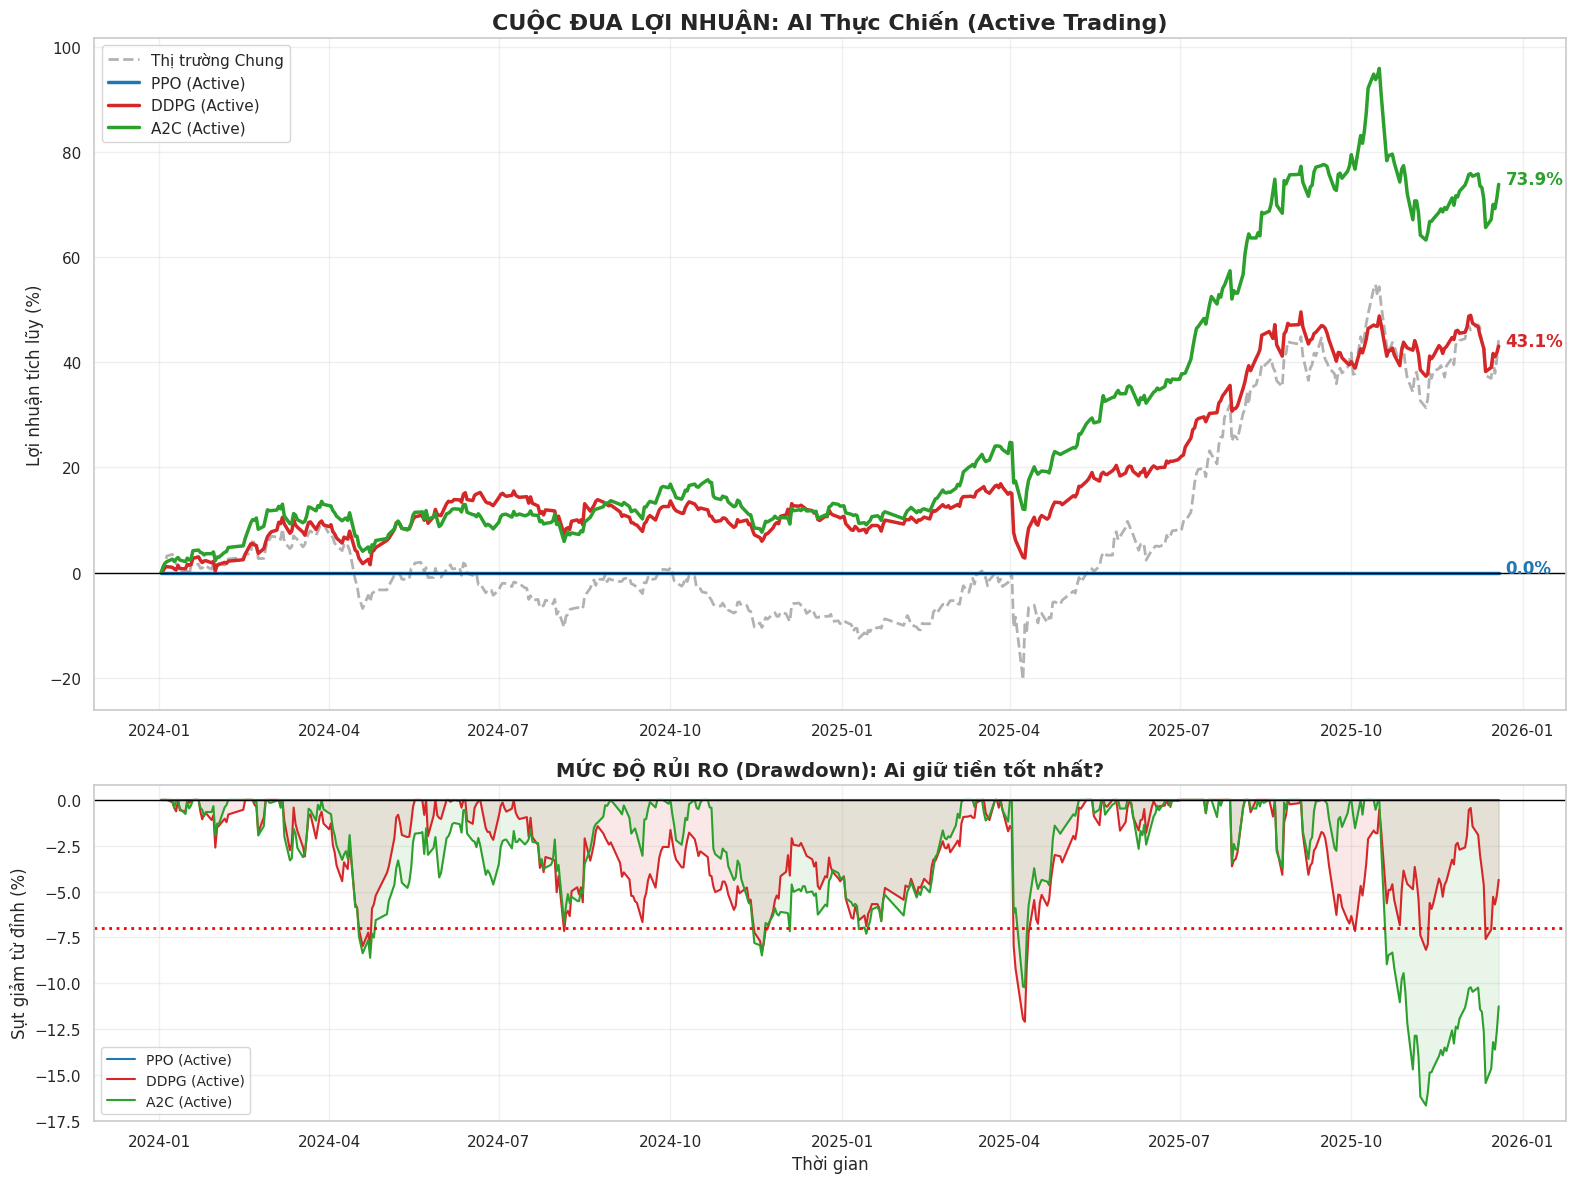


🏆 BẢNG TỔNG SẮP CUỐI CÙNG:
MODEL           | LỢI NHUẬN    | SỤT GIẢM MAX (DD)    | ĐÁNH GIÁ
---------------------------------------------------------------------------
PPO (Active)    |      0.00%  |               0.00%  | ⭐
DDPG (Active)   |     43.09%  |             -12.10%  | ⭐⭐⭐
A2C (Active)    |     73.87%  |             -16.67%  | ⭐⭐
---------------------------------------------------------------------------


In [10]:
# ==============================================================================
# CELL 5: VẼ BIỂU ĐỒ SO SÁNH CHI TIẾT (PROFIT & DRAWDOWN)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Cấu hình giao diện
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 10)

# 1. CHUẨN BỊ DỮ LIỆU
if 'results' not in globals() or not results:
    print("❌ Chưa có dữ liệu kết quả. Hãy chạy Cell 3 (Backtest) trước!")
else:
    # Lấy danh sách ngày
    dates = test_df.date.unique()
    df_plot = pd.DataFrame({'date': dates})

    # Đưa dữ liệu các model vào DataFrame
    for name, values in results.items():
        # Xử lý độ dài mảng (cắt hoặc thêm cho khớp ngày)
        if len(values) > len(dates): values = values[:len(dates)]
        elif len(values) < len(dates): values = np.pad(values, (0, len(dates)-len(values)), 'edge')

        # Chuyển đổi sang % Lợi nhuận tích lũy
        initial = 1_000_000_000
        returns = (values / initial - 1) * 100
        df_plot[name] = returns

    # Thêm Benchmark (VN-Index hoặc VNM ETF)
    try:
        import yfinance as yf
        print("📉 Đang tải dữ liệu thị trường làm tham chiếu...")
        # Thử VNM (ETF Vietnam) vì dữ liệu ổn định hơn VNINDEX trên Yahoo
        bm_df = yf.download("VNM", start="2024-01-01", end="2025-12-31", progress=False)['Close']
        if isinstance(bm_df, pd.DataFrame) and not bm_df.empty:
             # Xử lý MultiIndex nếu có (Yahoo Finance mới)
            if isinstance(bm_df.columns, pd.MultiIndex):
                bm_df = bm_df.iloc[:, 0]

            bm_df = bm_df.reset_index()
            bm_df.columns = ['date', 'price']
            bm_df['date'] = bm_df['date'].dt.tz_localize(None) # Bỏ múi giờ để merge

            # Merge vào df_plot
            df_plot = df_plot.merge(bm_df, on='date', how='left').ffill().bfill()

            # Tính % Return cho Benchmark
            base_price = df_plot['price'].iloc[0]
            df_plot['Market (VNM ETF)'] = (df_plot['price'] / base_price - 1) * 100
            print("✅ Đã thêm Benchmark: VNM ETF")
    except Exception as e:
        print(f"⚠️ Không tải được Benchmark: {e}")

    # 2. VẼ BIỂU ĐỒ (2 Subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})

    # --- BIỂU ĐỒ 1: LỢI NHUẬN (%) ---
    colors = {'PPO (Active)': '#1f77b4', 'DDPG (Active)': '#d62728', 'A2C (Active)': '#2ca02c'}

    # Vẽ Benchmark nền
    if 'Market (VNM ETF)' in df_plot.columns:
        ax1.plot(df_plot['date'], df_plot['Market (VNM ETF)'],
                 label='Thị trường Chung', color='gray', linestyle='--', linewidth=2, alpha=0.6)

    # Vẽ các Model
    for name in results.keys():
        if name in df_plot.columns:
            ax1.plot(df_plot['date'], df_plot[name],
                     label=name, color=colors.get(name, 'blue'), linewidth=2.5)

            # Đánh dấu điểm cuối
            last_date = df_plot['date'].iloc[-1]
            last_val = df_plot[name].iloc[-1]
            ax1.annotate(f"{last_val:.1f}%", xy=(last_date, last_val), xytext=(5, 0),
                         textcoords='offset points', fontweight='bold', color=colors.get(name, 'blue'))

    ax1.set_title("CUỘC ĐUA LỢI NHUẬN: AI Thực Chiến (Active Trading)", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Lợi nhuận tích lũy (%)", fontsize=12)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(0, color='black', linewidth=1)

    # --- BIỂU ĐỒ 2: DRAWDOWN (ĐỘ SỤT GIẢM) ---
    # Drawdown = (Giá hiện tại - Đỉnh cao nhất lịch sử) / Đỉnh cao nhất lịch sử
    for name in results.keys():
        if name in df_plot.columns:
            # Tính Wealth (Vốn) từ % Return để tính Drawdown
            wealth = 1_000_000_000 * (1 + df_plot[name]/100)
            peak = wealth.cummax()
            drawdown = (wealth - peak) / peak * 100

            ax2.plot(df_plot['date'], drawdown, label=name, color=colors.get(name, 'blue'), linewidth=1.5)
            ax2.fill_between(df_plot['date'], drawdown, 0, color=colors.get(name, 'blue'), alpha=0.1)

    ax2.set_title("MỨC ĐỘ RỦI RO (Drawdown): Ai giữ tiền tốt nhất?", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Sụt giảm từ đỉnh (%)", fontsize=12)
    ax2.set_xlabel("Thời gian", fontsize=12)
    ax2.legend(loc='lower left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='black', linewidth=1)

    # Kẻ đường báo động -7% (Mức cắt lỗ)
    ax2.axhline(-7, color='red', linestyle=':', linewidth=2, label='Mức Cắt Lỗ (-7%)')

    plt.tight_layout()
    plt.show()

    # 3. BẢNG TỔNG SẮP
    print("\n🏆 BẢNG TỔNG SẮP CUỐI CÙNG:")
    print(f"{'MODEL':<15} | {'LỢI NHUẬN':<12} | {'SỤT GIẢM MAX (DD)':<20} | {'ĐÁNH GIÁ'}")
    print("-" * 75)

    for name in results.keys():
        if name in df_plot.columns:
            # Tính lại các chỉ số
            wealth = 1_000_000_000 * (1 + df_plot[name]/100)
            final_return = df_plot[name].iloc[-1]
            max_dd = ((wealth - wealth.cummax()) / wealth.cummax()).min() * 100

            # Đánh giá sơ bộ
            rating = "⭐⭐⭐" if final_return > 20 and max_dd > -15 else "⭐⭐" if final_return > 0 else "⭐"

            print(f"{name:<15} | {final_return:>9.2f}%  | {max_dd:>18.2f}%  | {rating}")
    print("-" * 75)

🕵️‍♂️ ĐANG TIẾN HÀNH GIẢI PHẪU DDPG...

📊 BÁO CÁO HOẠT ĐỘNG (DDPG ACTIVE)
1. TỔNG SỐ LỆNH MUA:       679 lệnh
2. TỔNG SỐ LỆNH BÁN:       155 lệnh
   - Bán chủ động (AI):    0
   - Bán cưỡng chế (TP/SL):155 (Kỷ luật thép)
----------------------------------------
💰 TÀI SẢN KHỞI ĐẦU:       1,000,000,000 VND
💰 TÀI SẢN KẾT THÚC:       1,430,901,482 VND
📈 LỢI NHUẬN TỔNG:         +43.09%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


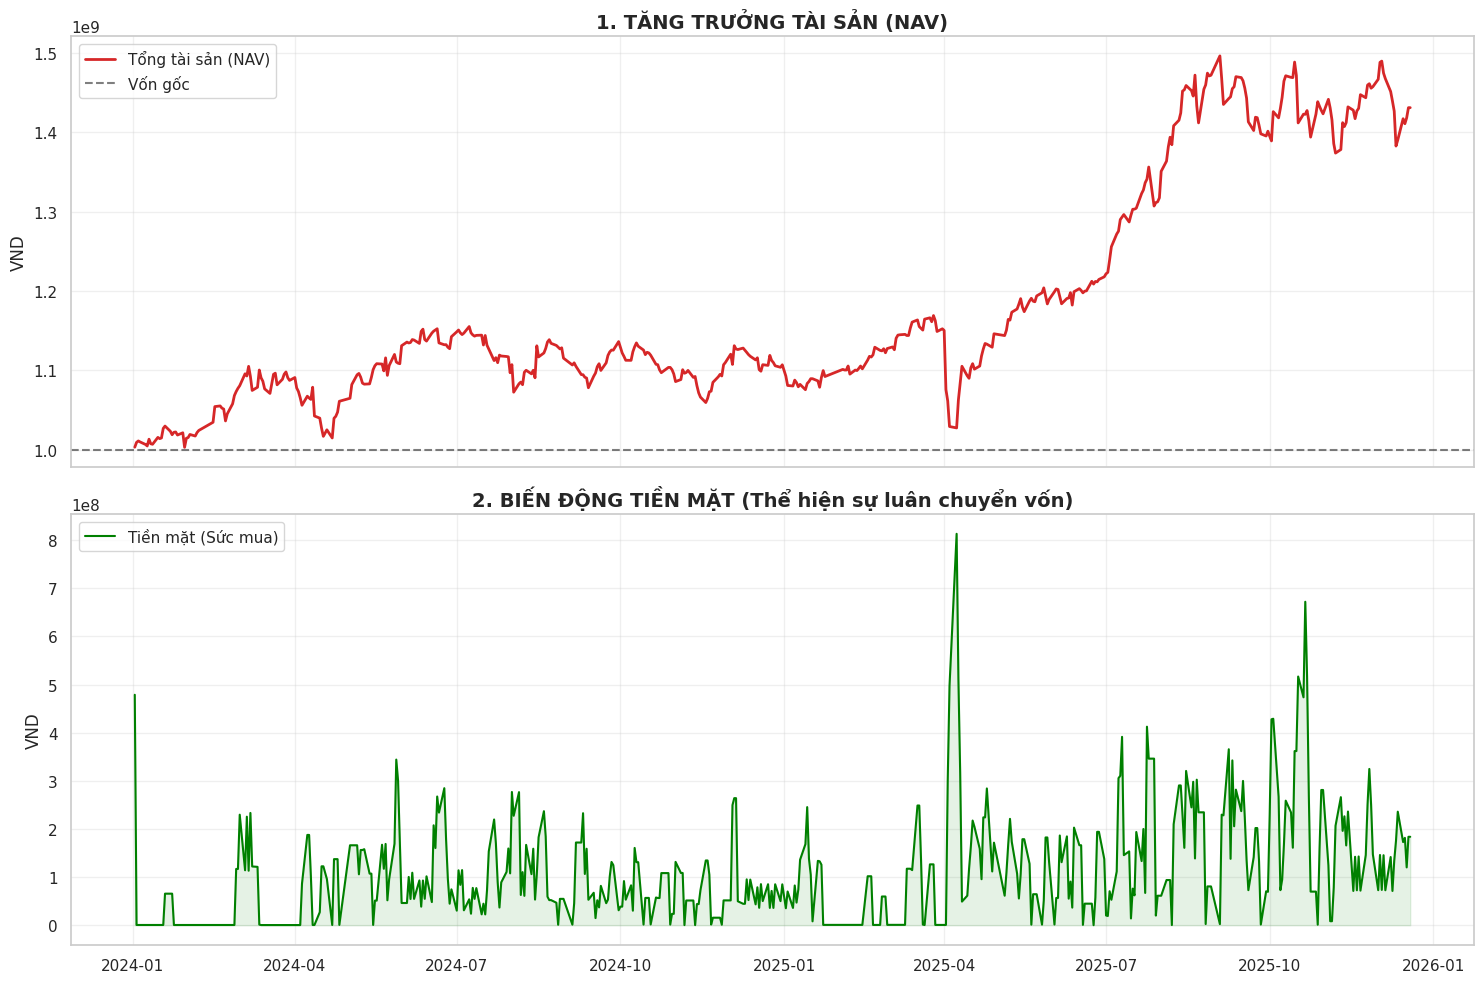

In [11]:
# ==============================================================================
# CELL 6: BÁO CÁO CHI TIẾT HOẠT ĐỘNG DDPG (AUDIT REPORT)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from stable_baselines3 import DDPG

# 1. Cấu hình & Load Model
model_path = "trained_models/ddpg_vn_agent"
if not os.path.exists(model_path + ".zip"):
    print("❌ Không tìm thấy model DDPG. Hãy đảm bảo bạn đã giải nén file zip.")
else:
    print("🕵️‍♂️ ĐANG TIẾN HÀNH GIẢI PHẪU DDPG...")

    # Khởi tạo môi trường
    env = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
    model = DDPG.load(model_path)

    # Các biến theo dõi
    state, _ = env.reset()
    done = False
    day_count = 0

    # Dữ liệu để vẽ biểu đồ
    dates = []
    account_values = []
    cash_balances = []

    # Thống kê lệnh
    count_buy = 0
    count_sell_active = 0 # AI chủ động bán
    count_force_sell = 0  # Bị chạm SL/TP

    # Lấy danh sách mã
    try: tickers = env.df.tic.unique().tolist()
    except: tickers = test_df.tic.unique().tolist()

    # Theo dõi holdings để suy luận hành động
    # (Vì env active tự động bán trong step, ta phải so sánh trước và sau)

    while not done:
        # Snapshot Trước
        holdings_before = np.array([env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)])

        # AI dự đoán
        action, _ = model.predict(state, deterministic=True)

        # Step
        state, _, done, _, _ = env.step(action)

        # Snapshot Sau
        holdings_after = np.array([env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)])
        pending_orders = env.stocks_pending[:, 0] # Lệnh mua vừa khớp (vào hàng chờ)

        # Lấy ngày
        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']
            dates.append(current_date)

        # Lưu tài sản & tiền mặt
        account_values.append(env.asset_memory[-1])
        cash_balances.append(env.state[0] + sum(env.cash_pending)) # Tiền mặt thực + Tiền đang về

        # --- PHÂN TÍCH HÀNH ĐỘNG ---
        for i in range(env.stock_dim):
            # 1. Đếm lệnh MUA (Dựa trên pending xuất hiện)
            if pending_orders[i] > 0:
                count_buy += 1

            # 2. Đếm lệnh BÁN (Dựa trên sụt giảm holding)
            # Lưu ý: holding giảm là đã bán xong.
            change = holdings_after[i] - holdings_before[i]
            if change < 0:
                # Nếu action < 0: AI chủ động bán
                # Nếu action >= 0: AI không bán mà hàng mất -> Force Sell
                if action[i] < 0:
                    count_sell_active += 1
                else:
                    count_force_sell += 1

        day_count += 1

    # --- HIỂN THỊ BÁO CÁO ---
    print("\n" + "="*40)
    print("📊 BÁO CÁO HOẠT ĐỘNG (DDPG ACTIVE)")
    print("="*40)
    print(f"1. TỔNG SỐ LỆNH MUA:       {count_buy} lệnh")
    print(f"2. TỔNG SỐ LỆNH BÁN:       {count_sell_active + count_force_sell} lệnh")
    print(f"   - Bán chủ động (AI):    {count_sell_active}")
    print(f"   - Bán cưỡng chế (TP/SL):{count_force_sell} (Kỷ luật thép)")
    print("-" * 40)
    print(f"💰 TÀI SẢN KHỞI ĐẦU:       1,000,000,000 VND")
    print(f"💰 TÀI SẢN KẾT THÚC:       {account_values[-1]:,.0f} VND")
    profit = (account_values[-1] / 1_000_000_000 - 1) * 100
    print(f"📈 LỢI NHUẬN TỔNG:         {profit:+.2f}%")
    print("="*40)

    # --- VẼ BIỂU ĐỒ ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # Chart 1: Tổng tài sản (NAV)
    ax1.plot(dates, account_values, color='#d62728', linewidth=2, label='Tổng tài sản (NAV)')
    ax1.axhline(1_000_000_000, color='black', linestyle='--', alpha=0.5, label='Vốn gốc')
    ax1.set_title("1. TĂNG TRƯỞNG TÀI SẢN (NAV)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("VND", fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Chart 2: Tiền mặt (Cash Flow) - Để xem có xoay vòng vốn không
    ax2.plot(dates, cash_balances, color='green', linewidth=1.5, label='Tiền mặt (Sức mua)')
    ax2.fill_between(dates, cash_balances, 0, color='green', alpha=0.1)
    ax2.set_title("2. BIẾN ĐỘNG TIỀN MẶT (Thể hiện sự luân chuyển vốn)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("VND", fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [12]:
# ==============================================================================
# CELL 7: XUẤT DANH SÁCH CHI TIẾT CÁC LỆNH MUA (KHỚP LỆNH THỰC TẾ)
# ==============================================================================
import pandas as pd
from stable_baselines3 import DDPG
import os

# 1. Load Model & Environment
model_path = "trained_models/ddpg_vn_agent"
if os.path.exists(model_path + ".zip"):
    print("🕵️‍♂️ Đang trích xuất dữ liệu MUA của DDPG...")

    # Tái tạo môi trường Active
    env = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
    model = DDPG.load(model_path)

    state, _ = env.reset()
    done = False
    day_count = 0

    buy_history = []

    # Lấy danh sách mã
    try: tickers = env.df.tic.unique().tolist()
    except: tickers = test_df.tic.unique().tolist()

    while not done:
        # AI dự đoán hành động
        action, _ = model.predict(state, deterministic=True)

        # Bước qua 1 ngày
        state, _, done, _, _ = env.step(action)

        # Lấy ngày hiện tại
        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']

            # KIỂM TRA KHO HÀNG CHỜ (PENDING)
            # Nếu có hàng trong pending[0], nghĩa là lệnh mua vừa khớp hôm nay
            for i in range(env.stock_dim):
                qty_bought = env.stocks_pending[i][0]

                if qty_bought > 0:
                    price = state[1 + i] # Giá đóng cửa ngày hôm đó
                    val = qty_bought * price

                    buy_history.append({
                        'Ngày': current_date,
                        'Mã CP': tickers[i],
                        'Giá Mua': price,
                        'Số lượng': int(qty_bought),
                        'Tổng giá trị': int(val)
                    })

        day_count += 1

    # --- HIỂN THỊ KẾT QUẢ ---
    df_buy = pd.DataFrame(buy_history)

    if not df_buy.empty:
        df_buy['Ngày'] = pd.to_datetime(df_buy['Ngày']).dt.date

        print(f"\n✅ TỔNG CỘNG: {len(df_buy)} LỆNH MUA ĐÃ KHỚP.")
        print(f"💰 Tổng tiền đã giải ngân: {df_buy['Tổng giá trị'].sum():,.0f} VND")

        print("\n📜 DANH SÁCH 20 LỆNH MUA ĐẦU TIÊN:")
        display(df_buy.head(20))

        print("\n📜 DANH SÁCH 20 LỆNH MUA GẦN NHẤT:")
        display(df_buy.tail(20))

        # Thống kê top cổ phiếu được mua nhiều nhất
        print("\n🏆 TOP 10 CỔ PHIẾU ĐƯỢC GOM NHIỀU NHẤT (Theo số lần mua):")
        print(df_buy['Mã CP'].value_counts().head(10))

        # Lưu file
        df_buy.to_csv("DDPG_Buy_Orders.csv", index=False)
        print("\n💾 Đã lưu danh sách đầy đủ vào file: 'DDPG_Buy_Orders.csv'")

    else:
        print("⚠️ Model không thực hiện lệnh mua nào (Hoặc không đủ tiền/điều kiện).")

else:
    print("❌ Không tìm thấy model DDPG.")

🕵️‍♂️ Đang trích xuất dữ liệu MUA của DDPG...

✅ TỔNG CỘNG: 679 LỆNH MUA ĐÃ KHỚP.
💰 Tổng tiền đã giải ngân: 18,650,397,035 VND

📜 DANH SÁCH 20 LỆNH MUA ĐẦU TIÊN:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã CP,Giá Mua,Số lượng,Tổng giá trị
0,2024-01-02,BVH,38155.269531,1300,49601850
1,2024-01-02,FPT,70155.953125,700,49109167
2,2024-01-02,HPG,21060.605469,2300,48439392
3,2024-01-02,MBB,12053.425781,4200,50624388
4,2024-01-02,MSN,68900.000000,700,48230000
5,2024-01-02,MWG,42251.375000,1200,50701650
6,2024-01-02,POW,9579.832031,5000,47899160
7,2024-01-02,SHB,8144.144043,5000,40720720
8,2024-01-02,SSB,20511.412109,2300,47176247
9,2024-01-02,VJC,107700.000000,400,43080000



📜 DANH SÁCH 20 LỆNH MUA GẦN NHẤT:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Ngày,Mã CP,Giá Mua,Số lượng,Tổng giá trị
659,2025-11-28,VRE,34900.0,2100,73290000
660,2025-12-01,BVH,51700.0,200,10340000
661,2025-12-01,HPG,26500.0,100,2650000
662,2025-12-01,VJC,217900.0,300,65370000
663,2025-12-03,VRE,34400.0,2100,72240000
664,2025-12-05,SHB,16600.0,100,1660000
665,2025-12-05,VRE,32950.0,2100,69195000
666,2025-12-09,VRE,30000.0,2200,66000000
667,2025-12-11,VRE,27450.0,2400,65880000
668,2025-12-15,MBB,24450.0,100,2445000



🏆 TOP 10 CỔ PHIẾU ĐƯỢC GOM NHIỀU NHẤT (Theo số lần mua):
Mã CP
POW    102
MSN     94
VRE     94
MWG     76
HPG     67
MBB     53
SHB     48
SSB     48
BVH     36
VJC     32
Name: count, dtype: int64

💾 Đã lưu danh sách đầy đủ vào file: 'DDPG_Buy_Orders.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🕵️‍♂️ ĐANG KIỂM TRA DÒNG TIỀN CỦA DDPG...

✅ KẾT QUẢ KIỂM TRA SỐ DƯ TIỀN (SOLVENCY CHECK)
💰 Vốn ban đầu:              1,000,000,000 VND
📉 Số dư tiền thấp nhất:     196 VND
🎉 KẾT LUẬN: AN TOÀN! Tài khoản chưa bao giờ bị âm tiền.
   (Model luôn tuân thủ quy tắc: Có tiền mới được mua).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


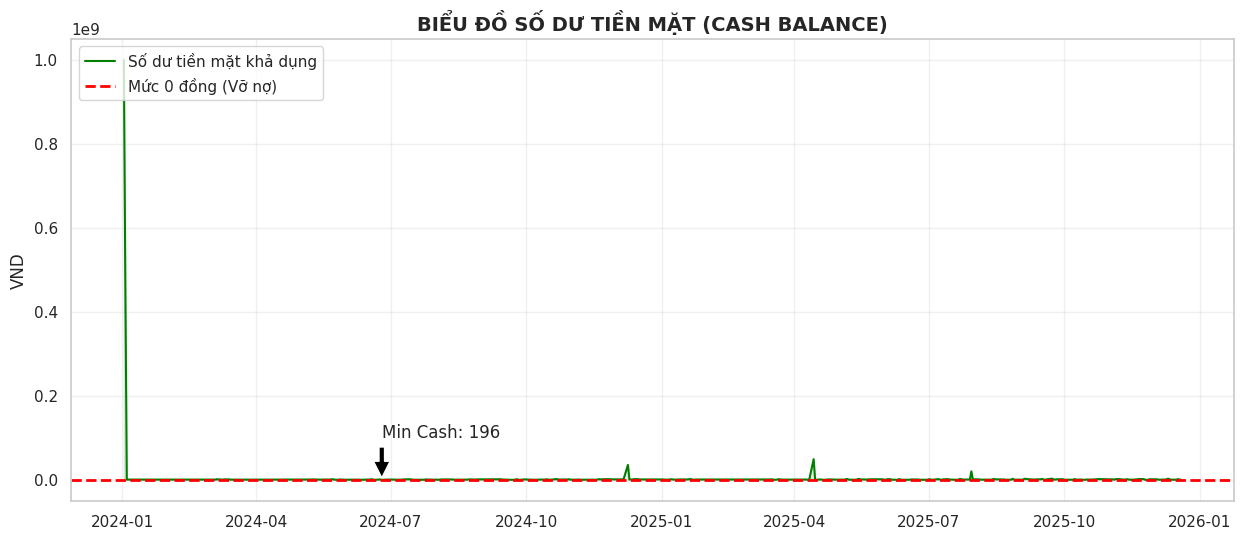

In [13]:
# ==============================================================================
# CELL 8: KIỂM TRA "SỨC KHỎE TÀI CHÍNH" (CASH FLOW AUDIT)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from stable_baselines3 import DDPG
import os

model_path = "trained_models/ddpg_vn_agent"

if os.path.exists(model_path + ".zip"):
    print("🕵️‍♂️ ĐANG KIỂM TRA DÒNG TIỀN CỦA DDPG...")

    env = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
    model = DDPG.load(model_path)

    state, _ = env.reset()
    done = False
    day_count = 0

    cash_history = []
    dates = []

    # Lấy danh sách mã
    try: tickers = env.df.tic.unique().tolist()
    except: tickers = test_df.tic.unique().tolist()

    min_cash = 1_000_000_000 # Khởi tạo max

    while not done:
        # 1. Lấy số dư tiền mặt TRƯỚC khi hành động
        current_cash = env.state[0]

        # Cập nhật mức tiền thấp nhất từng ghi nhận
        if current_cash < min_cash:
            min_cash = current_cash

        # Lấy ngày
        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']
            dates.append(current_date)
            cash_history.append(current_cash)

        # 2. Hành động
        action, _ = model.predict(state, deterministic=True)
        state, _, done, _, _ = env.step(action)

        day_count += 1

    # --- BÁO CÁO KIỂM TOÁN ---
    print("\n" + "="*50)
    print("✅ KẾT QUẢ KIỂM TRA SỐ DƯ TIỀN (SOLVENCY CHECK)")
    print("="*50)
    print(f"💰 Vốn ban đầu:              1,000,000,000 VND")
    print(f"📉 Số dư tiền thấp nhất:     {min_cash:,.0f} VND")

    if min_cash >= 0:
        print("🎉 KẾT LUẬN: AN TOÀN! Tài khoản chưa bao giờ bị âm tiền.")
        print("   (Model luôn tuân thủ quy tắc: Có tiền mới được mua).")
    else:
        print(f"⚠️ CẢNH BÁO: NGUY HIỂM! Tài khoản bị âm {min_cash:,.0f} VND.")
        print("   (Cần xem lại logic môi trường ngay lập tức).")
    print("="*50)

    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(15, 6))

    # Vẽ đường số dư tiền mặt
    plt.plot(dates, cash_history, color='green', linewidth=1.5, label='Số dư tiền mặt khả dụng')

    # Vẽ đường 0 (Mức tử thần)
    plt.axhline(0, color='red', linewidth=2, linestyle='--', label='Mức 0 đồng (Vỡ nợ)')

    # Tô màu vùng an toàn
    plt.fill_between(dates, cash_history, 0, color='green', alpha=0.1)

    plt.title("BIỂU ĐỒ SỐ DƯ TIỀN MẶT (CASH BALANCE)", fontsize=14, fontweight='bold')
    plt.ylabel("VND", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)

    # Hiển thị chú thích tại điểm thấp nhất
    min_idx = np.argmin(cash_history)
    plt.annotate(f'Min Cash: {min_cash:,.0f}',
                 xy=(dates[min_idx], min_cash),
                 xytext=(dates[min_idx], min_cash + 100_000_000),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()

else:
    print("❌ Không tìm thấy model.")

🕵️‍♂️ ĐANG PHÂN TÍCH DÒNG TIỀN RA/VÀO...


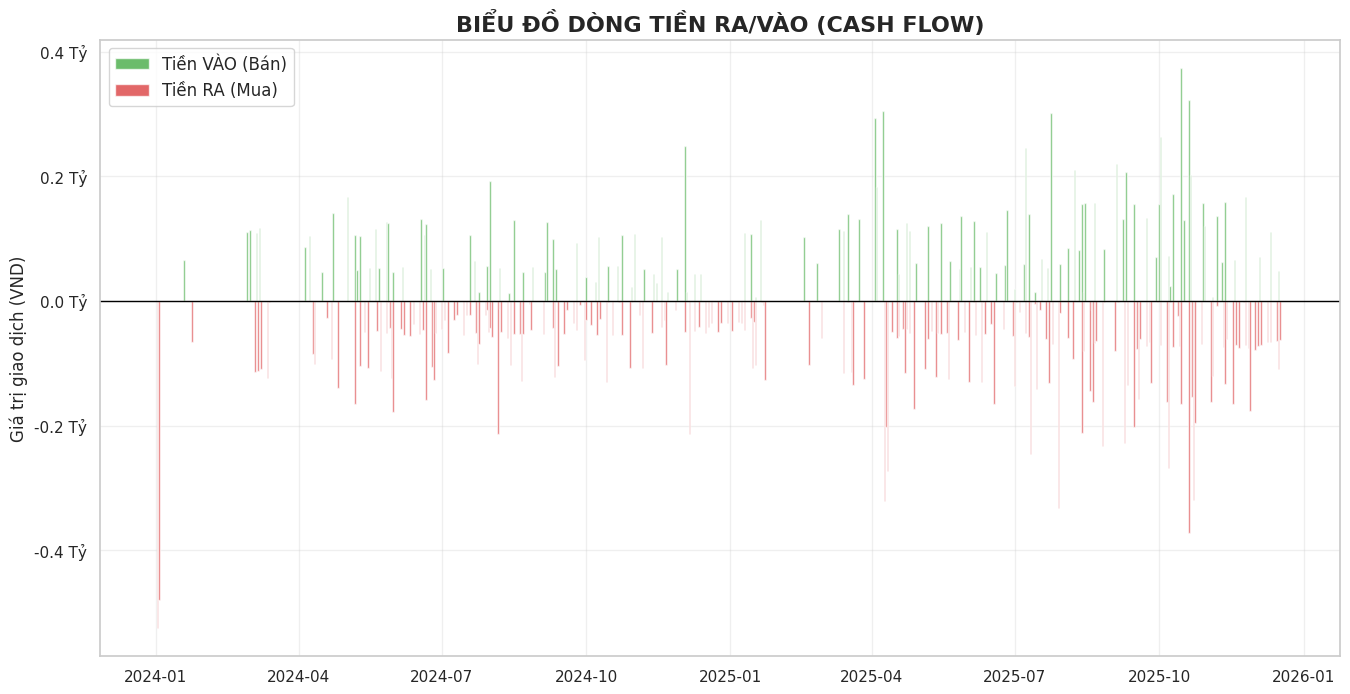


📊 THỐNG KÊ DÒNG TIỀN (CASH FLOW SUMMARY)
🔴 TỔNG TIỀN ĐÃ CHI MUA:   18,650,397,207 VND
🟢 TỔNG TIỀN ĐÃ THU BÁN:   13,641,498,642 VND
⚖️ DÒNG TIỀN RÒNG (NET):    -5,008,898,565 VND


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# ==============================================================================
# CELL 9: BIỂU ĐỒ DÒNG TIỀN MUA/BÁN (CASH FLOW IN/OUT)
# ==============================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from stable_baselines3 import DDPG
import os

# Cấu hình
model_path = "trained_models/ddpg_vn_agent"

if 'test_df' in globals() and os.path.exists(model_path + ".zip"):
    print("🕵️‍♂️ ĐANG PHÂN TÍCH DÒNG TIỀN RA/VÀO...")

    # 1. Khởi tạo
    env = StockTradingEnvVietnam_Active(df=test_df, **env_kwargs)
    model = DDPG.load(model_path)

    state, _ = env.reset()
    done = False
    day_count = 0

    # Danh sách lưu dữ liệu
    dates = []
    money_out = [] # Tiền chi ra để MUA (Số âm)
    money_in = []  # Tiền thu về từ BÁN (Số dương)

    try: tickers = env.df.tic.unique().tolist()
    except: tickers = test_df.tic.unique().tolist()

    while not done:
        # Snapshot trước khi step
        holdings_before = np.array([env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)])

        # Action
        action, _ = model.predict(state, deterministic=True)
        state, _, done, _, _ = env.step(action)

        # Snapshot sau khi step
        holdings_after = np.array([env.state[env.stock_dim + 1 + i] for i in range(env.stock_dim)])

        # Lấy ngày
        if day_count * len(tickers) < len(test_df):
            current_date = test_df.iloc[day_count * len(tickers)]['date']
            dates.append(current_date)

            # --- TÍNH TOÁN DÒNG TIỀN ---
            daily_buy_val = 0
            daily_sell_val = 0

            # Lấy giá hiện tại
            current_prices = np.array([state[1 + i] for i in range(env.stock_dim)])

            for i in range(env.stock_dim):
                # 1. TÍNH TIỀN MUA (Dựa trên pending mới xuất hiện)
                qty_bought = env.stocks_pending[i][0]
                if qty_bought > 0:
                    daily_buy_val += qty_bought * current_prices[i]

                # 2. TÍNH TIỀN BÁN (Dựa trên sụt giảm holding)
                change = holdings_after[i] - holdings_before[i]
                if change < 0:
                    qty_sold = abs(change)
                    daily_sell_val += qty_sold * current_prices[i]

            # Lưu vào list (Mua để dấu âm để vẽ biểu đồ hướng xuống)
            money_out.append(-daily_buy_val)
            money_in.append(daily_sell_val)

        day_count += 1

    # --- VẼ BIỂU ĐỒ ---
    fig, ax = plt.subplots(figsize=(16, 8))

    # Vẽ cột Tiền BÁN (Màu xanh, hướng lên)
    ax.bar(dates, money_in, color='#2ca02c', label='Tiền VÀO (Bán)', width=1.0, alpha=0.7)

    # Vẽ cột Tiền MUA (Màu đỏ, hướng xuống)
    ax.bar(dates, money_out, color='#d62728', label='Tiền RA (Mua)', width=1.0, alpha=0.7)

    # Đường 0
    ax.axhline(0, color='black', linewidth=1)

    # Trang trí
    ax.set_title("BIỂU ĐỒ DÒNG TIỀN RA/VÀO (CASH FLOW)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Giá trị giao dịch (VND)", fontsize=12)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Format trục Y sang dạng tỷ đồng cho gọn
    def millions(x, pos):
        return '%1.1f Tỷ' % (x * 1e-9)
    from matplotlib.ticker import FuncFormatter
    formatter = FuncFormatter(millions)
    ax.yaxis.set_major_formatter(formatter)

    # Thống kê nhanh
    total_buy = -sum(money_out)
    total_sell = sum(money_in)
    net_flow = total_sell - total_buy

    plt.show()

    print("\n" + "="*40)
    print("📊 THỐNG KÊ DÒNG TIỀN (CASH FLOW SUMMARY)")
    print("="*40)
    print(f"🔴 TỔNG TIỀN ĐÃ CHI MUA:   {total_buy:,.0f} VND")
    print(f"🟢 TỔNG TIỀN ĐÃ THU BÁN:   {total_sell:,.0f} VND")
    print(f"⚖️ DÒNG TIỀN RÒNG (NET):    {net_flow:+,.0f} VND")
    print("="*40)

else:
    print("❌ Thiếu dữ liệu hoặc model. Hãy chạy lại các Cell trước.")